# Capstone Project — Data Scientist
## Prediksi Performa Belajar Siswa

### Problem Discovery

**Latar Belakang:**
Performa belajar siswa dipengaruhi oleh banyak faktor — mulai dari jam belajar, kehadiran, dukungan orang tua, hingga kualitas guru dan akses terhadap sumber belajar. Memahami faktor-faktor ini secara komprehensif sangat penting untuk memberikan intervensi yang tepat.

**Permasalahan:**
Sulit untuk mengidentifikasi secara akurat faktor mana yang paling berpengaruh terhadap performa belajar siswa, dan bagaimana kombinasi faktor-faktor tersebut mempengaruhi hasil akhir.

**Solusi:**
Membangun aplikasi prediksi performa belajar siswa berbasis machine learning. User (pelajar) memasukkan data profil mereka, kemudian model akan memprediksi performa belajarnya saat ini (`Performance_Category`: Low / Medium / High).

## Business Questions
1. Faktor-faktor apa yang paling berkontribusi terhadap klasifikasi performa siswa ke dalam kategori Low, Medium, dan High?
2. Profil atau karakteristik dominan apa yang dimiliki oleh siswa dengan performa rendah?
3. Berdasarkan pola historis data, intervensi akademik apa yang paling potensial untuk meningkatkan performa siswa?

## Data Wrangling
### Gathering Data

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
print('Libraries loaded.')

Libraries loaded.


In [30]:
# Load dataset
df = pd.read_csv('StudentPerformanceFactors.csv')
print(f'Dataset loaded: {df.shape[0]} baris, {df.shape[1]} kolom')
df.head()

Dataset loaded: 6654 baris, 20 kolom


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7.0,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8.0,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7.0,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8.0,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6.0,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


### Assessing Data
Mengevaluasi kualitas dan struktur data sebelum cleaning.

In [31]:
# Struktur data
print('=== Info Dataset ===')
df.info()
print(f'\nShape: {df.shape}')
print(f'Columns: {list(df.columns)}')

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6654 entries, 0 to 6653
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6654 non-null   int64  
 1   Attendance                  6654 non-null   int64  
 2   Parental_Involvement        6347 non-null   object 
 3   Access_to_Resources         6575 non-null   object 
 4   Extracurricular_Activities  6654 non-null   object 
 5   Sleep_Hours                 6477 non-null   float64
 6   Previous_Scores             6654 non-null   int64  
 7   Motivation_Level            6654 non-null   object 
 8   Internet_Access             6654 non-null   object 
 9   Tutoring_Sessions           6654 non-null   int64  
 10  Family_Income               6523 non-null   object 
 11  Teacher_Quality             6312 non-null   object 
 12  School_Type                 6415 non-null   object 
 13  Peer_Influen

In [32]:
# Statistik deskriptif
df.describe(include='all')

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
count,6654.000000,6654.000000,6347,6575,6654,6477.00000,6654.000000,6654,6654,6654.000000,6523,6312,6415,6654,6654.000000,6654,6564,6587,6654,6654.000000
unique,NaN,NaN,3,3,2,NaN,NaN,3,2,NaN,3,3,2,3,NaN,2,3,3,2,NaN
top,NaN,NaN,Medium,Medium,Yes,NaN,NaN,Medium,Yes,NaN,Medium,Medium,Public,Positive,NaN,No,High School,Near,Male,NaN
freq,NaN,NaN,3235,3314,3969,NaN,NaN,3371,6155,NaN,2647,3800,4469,2661,NaN,5948,3242,3914,3842,NaN
mean,20.306733,80.375263,NaN,NaN,NaN,7.02671,75.088218,NaN,NaN,1.495642,NaN,NaN,NaN,NaN,2.967989,NaN,NaN,NaN,NaN,67.240006
std,10.712460,21.698901,NaN,NaN,NaN,1.46286,14.393877,NaN,NaN,1.230614,NaN,NaN,NaN,NaN,1.030439,NaN,NaN,NaN,NaN,3.899645
min,1.000000,60.000000,NaN,NaN,NaN,4.00000,50.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,55.000000
25%,16.000000,70.000000,NaN,NaN,NaN,6.00000,63.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,65.000000
50%,20.000000,80.000000,NaN,NaN,NaN,7.00000,75.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,67.000000
75%,24.000000,90.000000,NaN,NaN,NaN,8.00000,88.000000,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,69.000000


In [33]:
# Evaluasi kualitas data
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Persen (%)': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

print(f'\n=== Duplikat ===')
print(f'Jumlah baris duplikat: {df.duplicated().sum()}')

print(f'\n=== Tipe Data ===')
print(df.dtypes.value_counts())

=== Missing Values ===
                          Missing  Persen (%)
Parental_Involvement          307        4.61
Access_to_Resources            79        1.19
Sleep_Hours                   177        2.66
Family_Income                 131        1.97
Teacher_Quality               342        5.14
School_Type                   239        3.59
Parental_Education_Level       90        1.35
Distance_from_Home             67        1.01

=== Duplikat ===
Jumlah baris duplikat: 56

=== Tipe Data ===
object     13
int64       6
float64     1
Name: count, dtype: int64


**Temuan Assessing Data:**
- Terdapat beberapa kolom dengan missing values yang perlu ditangani
- Terdapat baris duplikat yang perlu dihapus
- Dataset terdiri dari kolom numerik dan kategorikal

### Cleaning Data
Membersihkan dan mempersiapkan data sebelum masuk ke tahap analisis.

In [34]:
# Hapus duplicate
df = df.drop_duplicates().copy()

# ============================================================
# TIPE 1: Handle missing value NUMERIK dengan MEDIAN
# Alasan: Median robust terhadap outlier
# ============================================================
numeric_cols = df.select_dtypes(include=np.number).columns
numeric_missing = [col for col in numeric_cols if df[col].isnull().sum() > 0]

print('=== Handling Missing Value: Kolom NUMERIK (Median) ===')
for col in numeric_missing:
    median_val = df[col].median()
    count = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    print(f'  - {col}: {count} missing → median = {median_val}')
if not numeric_missing:
    print('  Tidak ada kolom numerik dengan missing value.')

# ============================================================
# TIPE 2: Handle missing value KATEGORIKAL dengan MODUS
# Alasan: Modus tepat untuk data non-numerik
# ============================================================
categorical_cols = df.select_dtypes(exclude=np.number).columns
categorical_missing = [col for col in categorical_cols if df[col].isnull().sum() > 0]

print('\n=== Handling Missing Value: Kolom KATEGORIKAL (Modus) ===')
for col in categorical_missing:
    mode_val = df[col].mode()[0]
    count = df[col].isnull().sum()
    df[col] = df[col].fillna(mode_val)
    print(f'  - {col}: {count} missing → modus = "{mode_val}"')
if not categorical_missing:
    print('  Tidak ada kolom kategorikal dengan missing value.')

print(f'\n=== Verifikasi: {df.isnull().sum().sum()} missing values tersisa ===')
print(f'Shape setelah cleaning: {df.shape}')

=== Handling Missing Value: Kolom NUMERIK (Median) ===
  - Sleep_Hours: 177 missing → median = 7.0

=== Handling Missing Value: Kolom KATEGORIKAL (Modus) ===
  - Parental_Involvement: 307 missing → modus = "Medium"
  - Access_to_Resources: 79 missing → modus = "Medium"
  - Family_Income: 131 missing → modus = "Low"
  - Teacher_Quality: 342 missing → modus = "Medium"
  - School_Type: 239 missing → modus = "Public"
  - Parental_Education_Level: 90 missing → modus = "High School"
  - Distance_from_Home: 67 missing → modus = "Near"

=== Verifikasi: 0 missing values tersisa ===
Shape setelah cleaning: (6598, 20)


In [35]:
# ============================================================
# HANDLING OUTLIER - IQR Method
# Menghilangkan outlier pada Hours_Studied dan Attendance
# ============================================================

print(f'Shape sebelum handling outlier: {df.shape}')

outlier_cols = ['Hours_Studied', 'Attendance']
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(df)
    df = df[(df[col] >= lower) & (df[col] <= upper)]
    removed = before - len(df)
    print(f'  {col}: {removed} outlier dihapus (range valid: {lower:.1f} - {upper:.1f})')

print(f'\nShape setelah handling outlier: {df.shape}')


Shape sebelum handling outlier: (6598, 20)
  Hours_Studied: 53 outlier dihapus (range valid: 4.0 - 36.0)
  Attendance: 3 outlier dihapus (range valid: 40.0 - 120.0)

Shape setelah handling outlier: (6542, 20)


## Exploratory Data Analysis (EDA)
### Distribusi & Korelasi

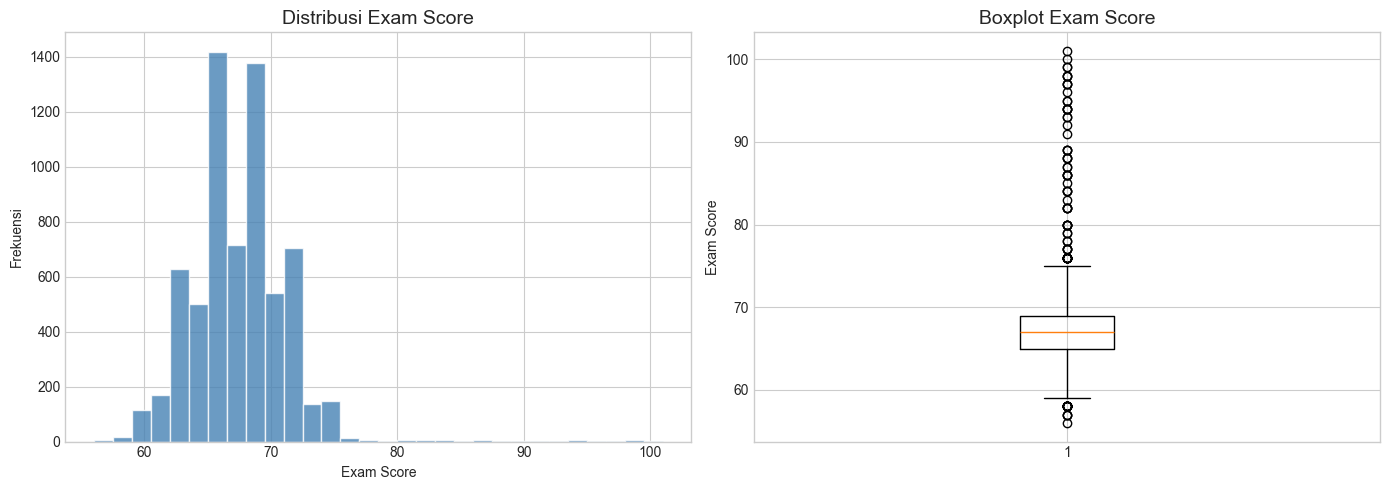

Mean: 67.23
Median: 67.00
Std: 3.85


In [36]:
# Distribusi Exam_Score (target asal)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Exam_Score'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribusi Exam Score', fontsize=14)
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Frekuensi')

axes[1].boxplot(df['Exam_Score'], vert=True)
axes[1].set_title('Boxplot Exam Score', fontsize=14)
axes[1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()

print(f'Mean: {df["Exam_Score"].mean():.2f}')
print(f'Median: {df["Exam_Score"].median():.2f}')
print(f'Std: {df["Exam_Score"].std():.2f}')

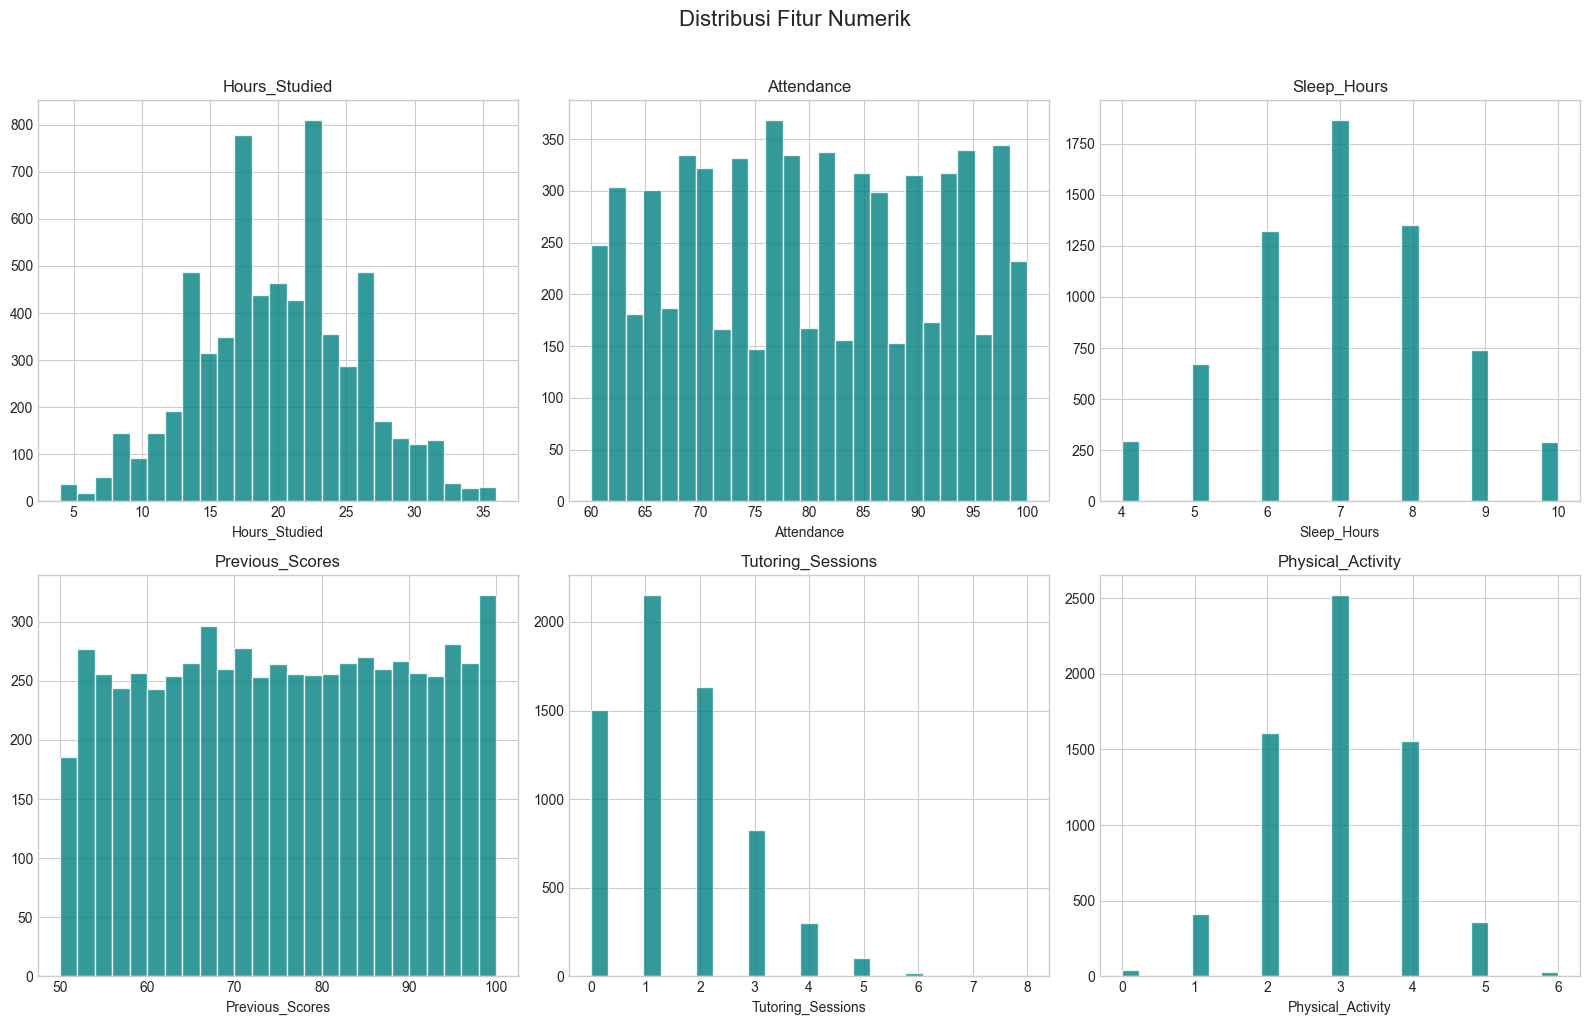

In [37]:
# Distribusi fitur numerik
num_cols = df.select_dtypes(include=np.number).columns.drop('Exam_Score')
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=25, color='teal', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel(col)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

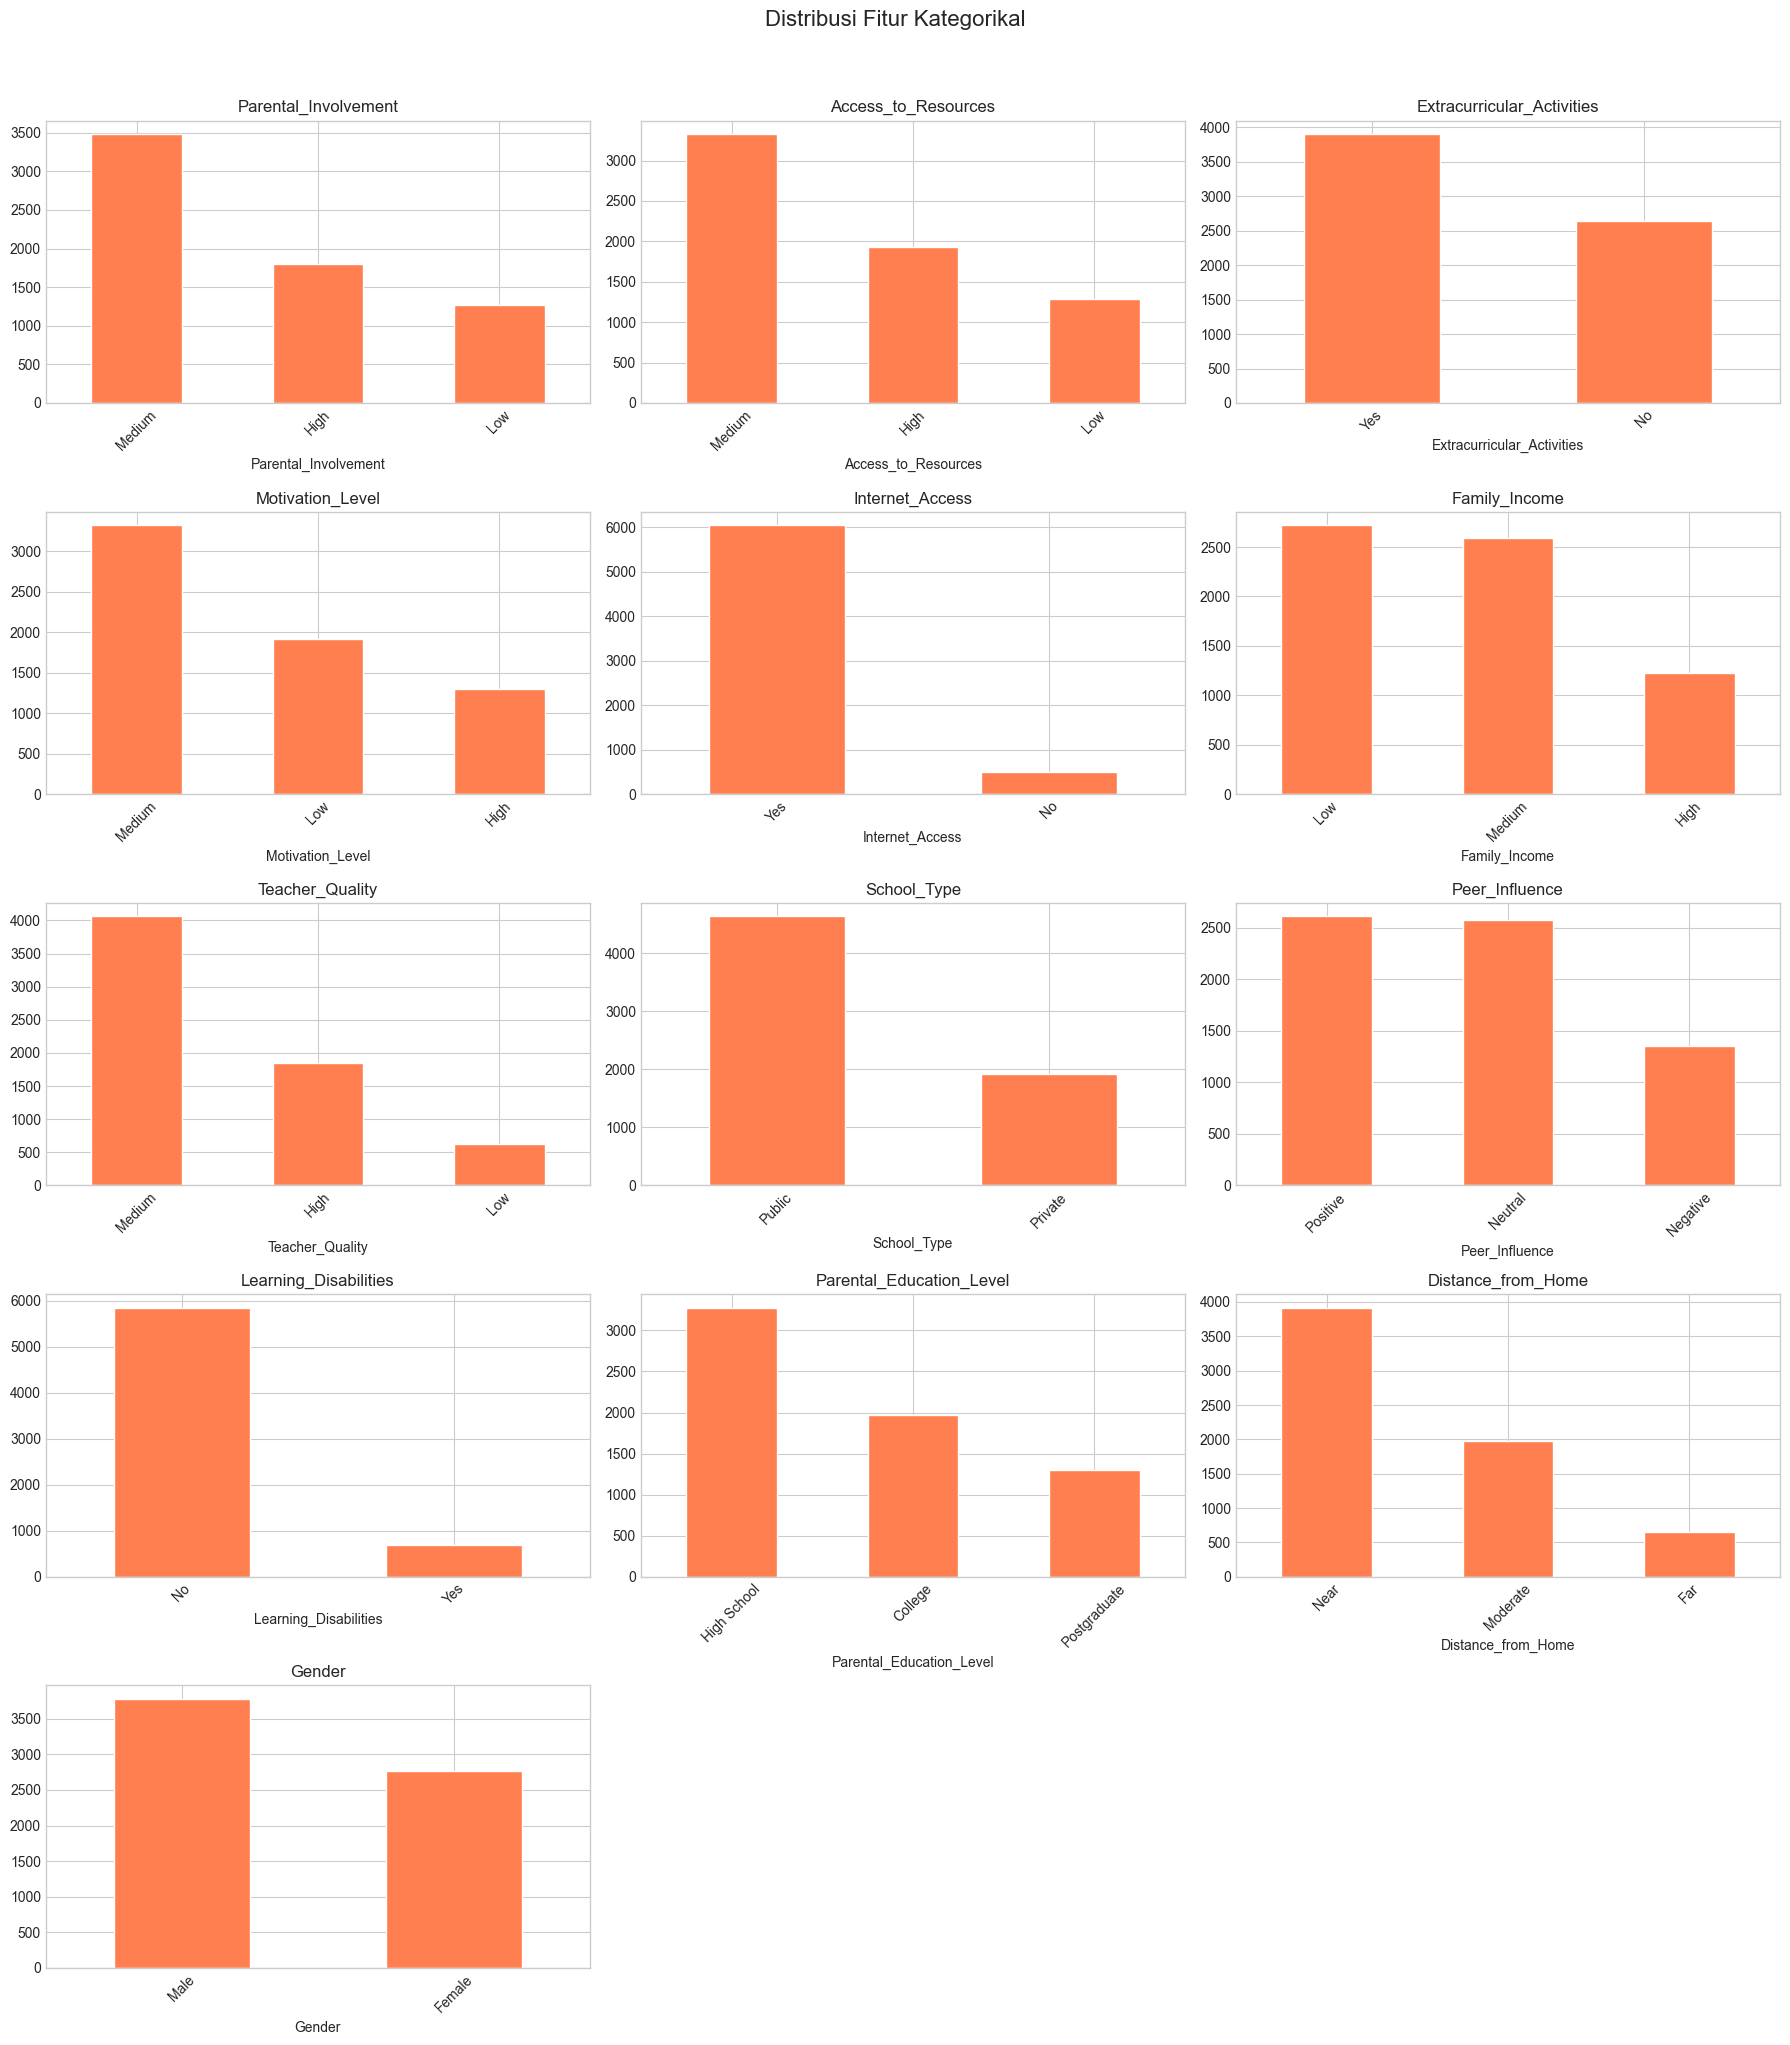

In [38]:
# Distribusi fitur kategorikal
cat_cols = df.select_dtypes(include='object').columns
n = len(cat_cols)
rows = (n + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(18, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='coral', edgecolor='white')
    axes[i].set_title(col, fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

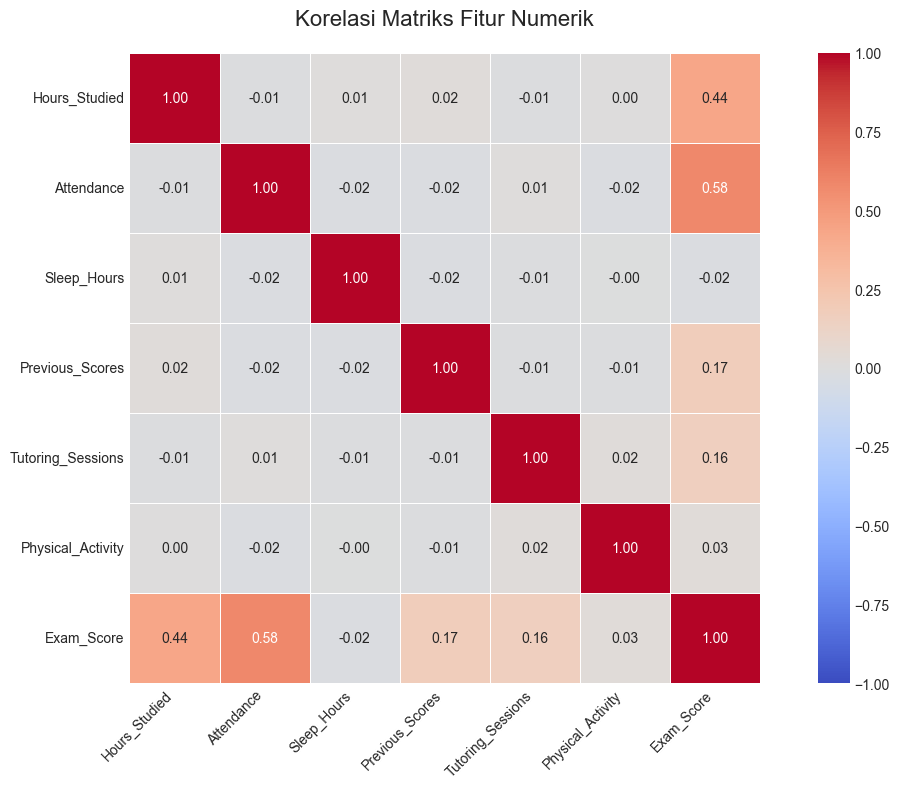


=== Korelasi terhadap Exam_Score ===
  Attendance               : +0.5836 (+) kuat
  Hours_Studied            : +0.4373 (+) sedang
  Previous_Scores          : +0.1739 (+) lemah
  Tutoring_Sessions        : +0.1569 (+) lemah
  Physical_Activity        : +0.0288 (+) lemah
  Sleep_Hours              : -0.0170 (-) lemah


In [39]:
# Korelasi Matriks fitur numerik
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Korelasi Matriks Fitur Numerik', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\n=== Korelasi terhadap Exam_Score ===')
exam_corr = corr_matrix['Exam_Score'].drop('Exam_Score').sort_values(ascending=False)
for feat, val in exam_corr.items():
    d = '(+)' if val > 0 else '(-)'
    s = 'kuat' if abs(val) > 0.5 else ('sedang' if abs(val) > 0.3 else 'lemah')
    print(f'  {feat:25s}: {val:+.4f} {d} {s}')

### Analisis Mendalam

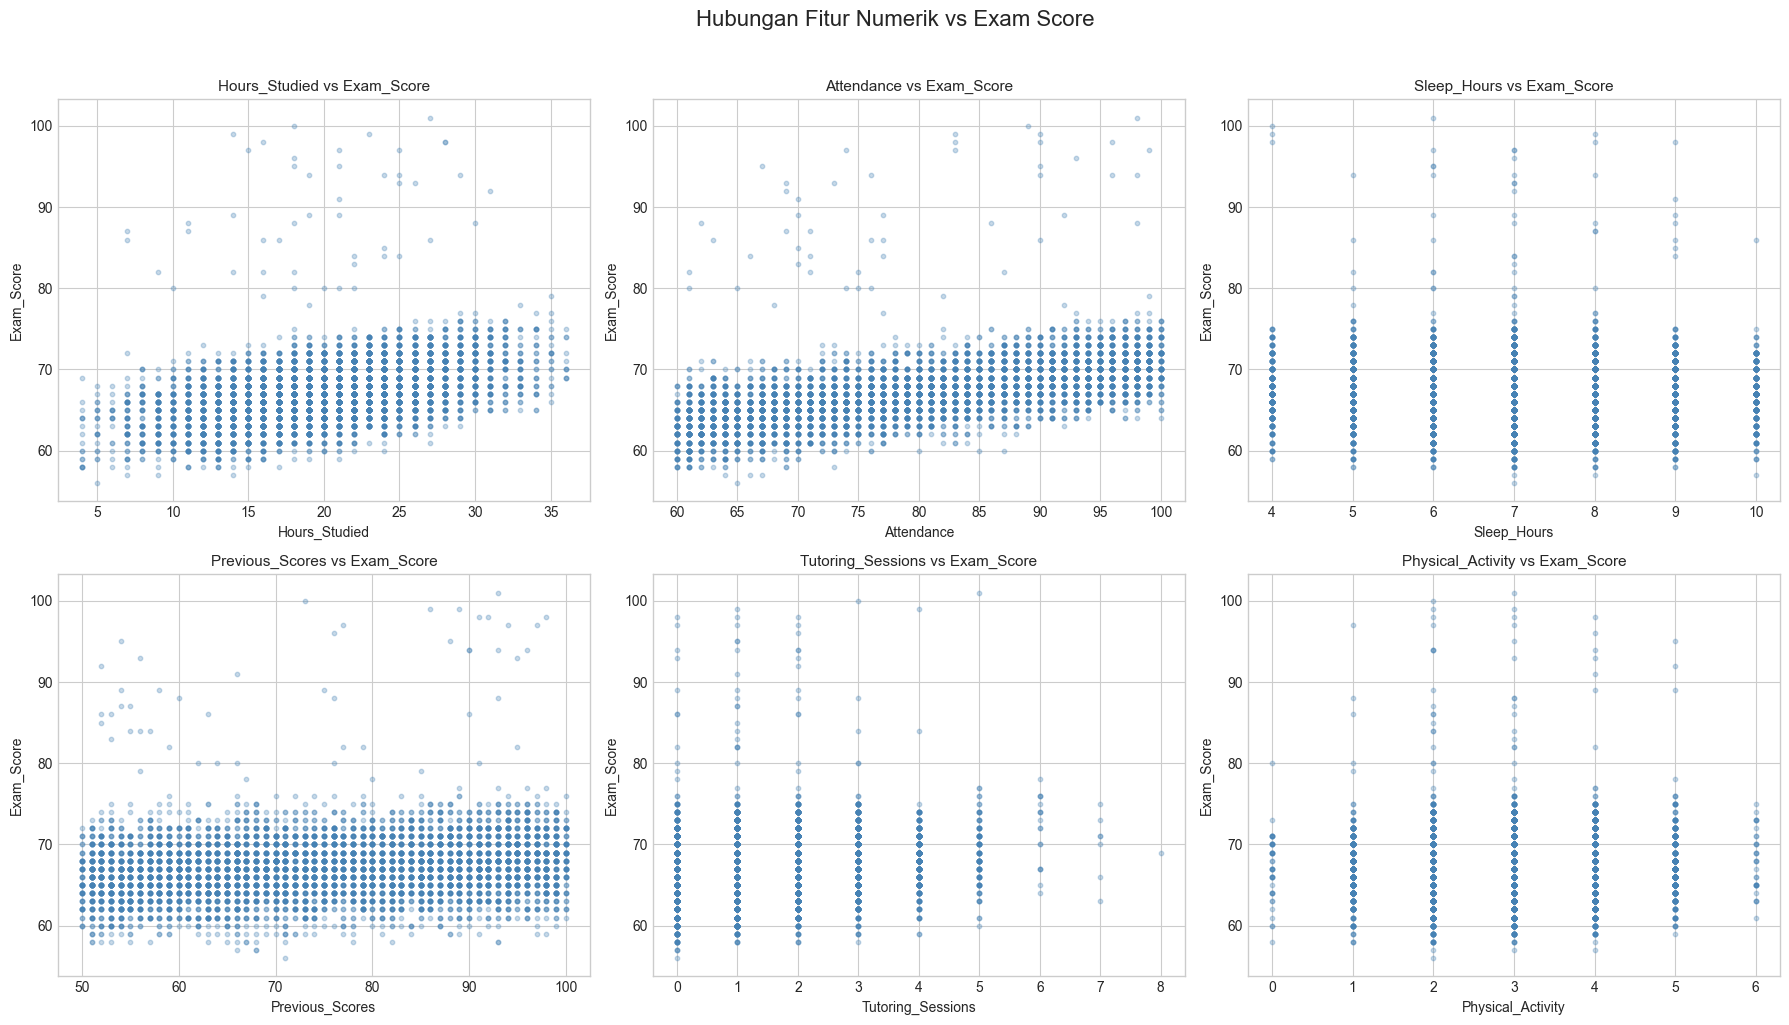

In [40]:
# Scatter plot fitur numerik vs Exam_Score
num_features = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
                'Tutoring_Sessions', 'Physical_Activity']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].scatter(df[col], df['Exam_Score'], alpha=0.3, s=10, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Exam_Score')
    axes[i].set_title(f'{col} vs Exam_Score', fontsize=11)

plt.suptitle('Hubungan Fitur Numerik vs Exam Score', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

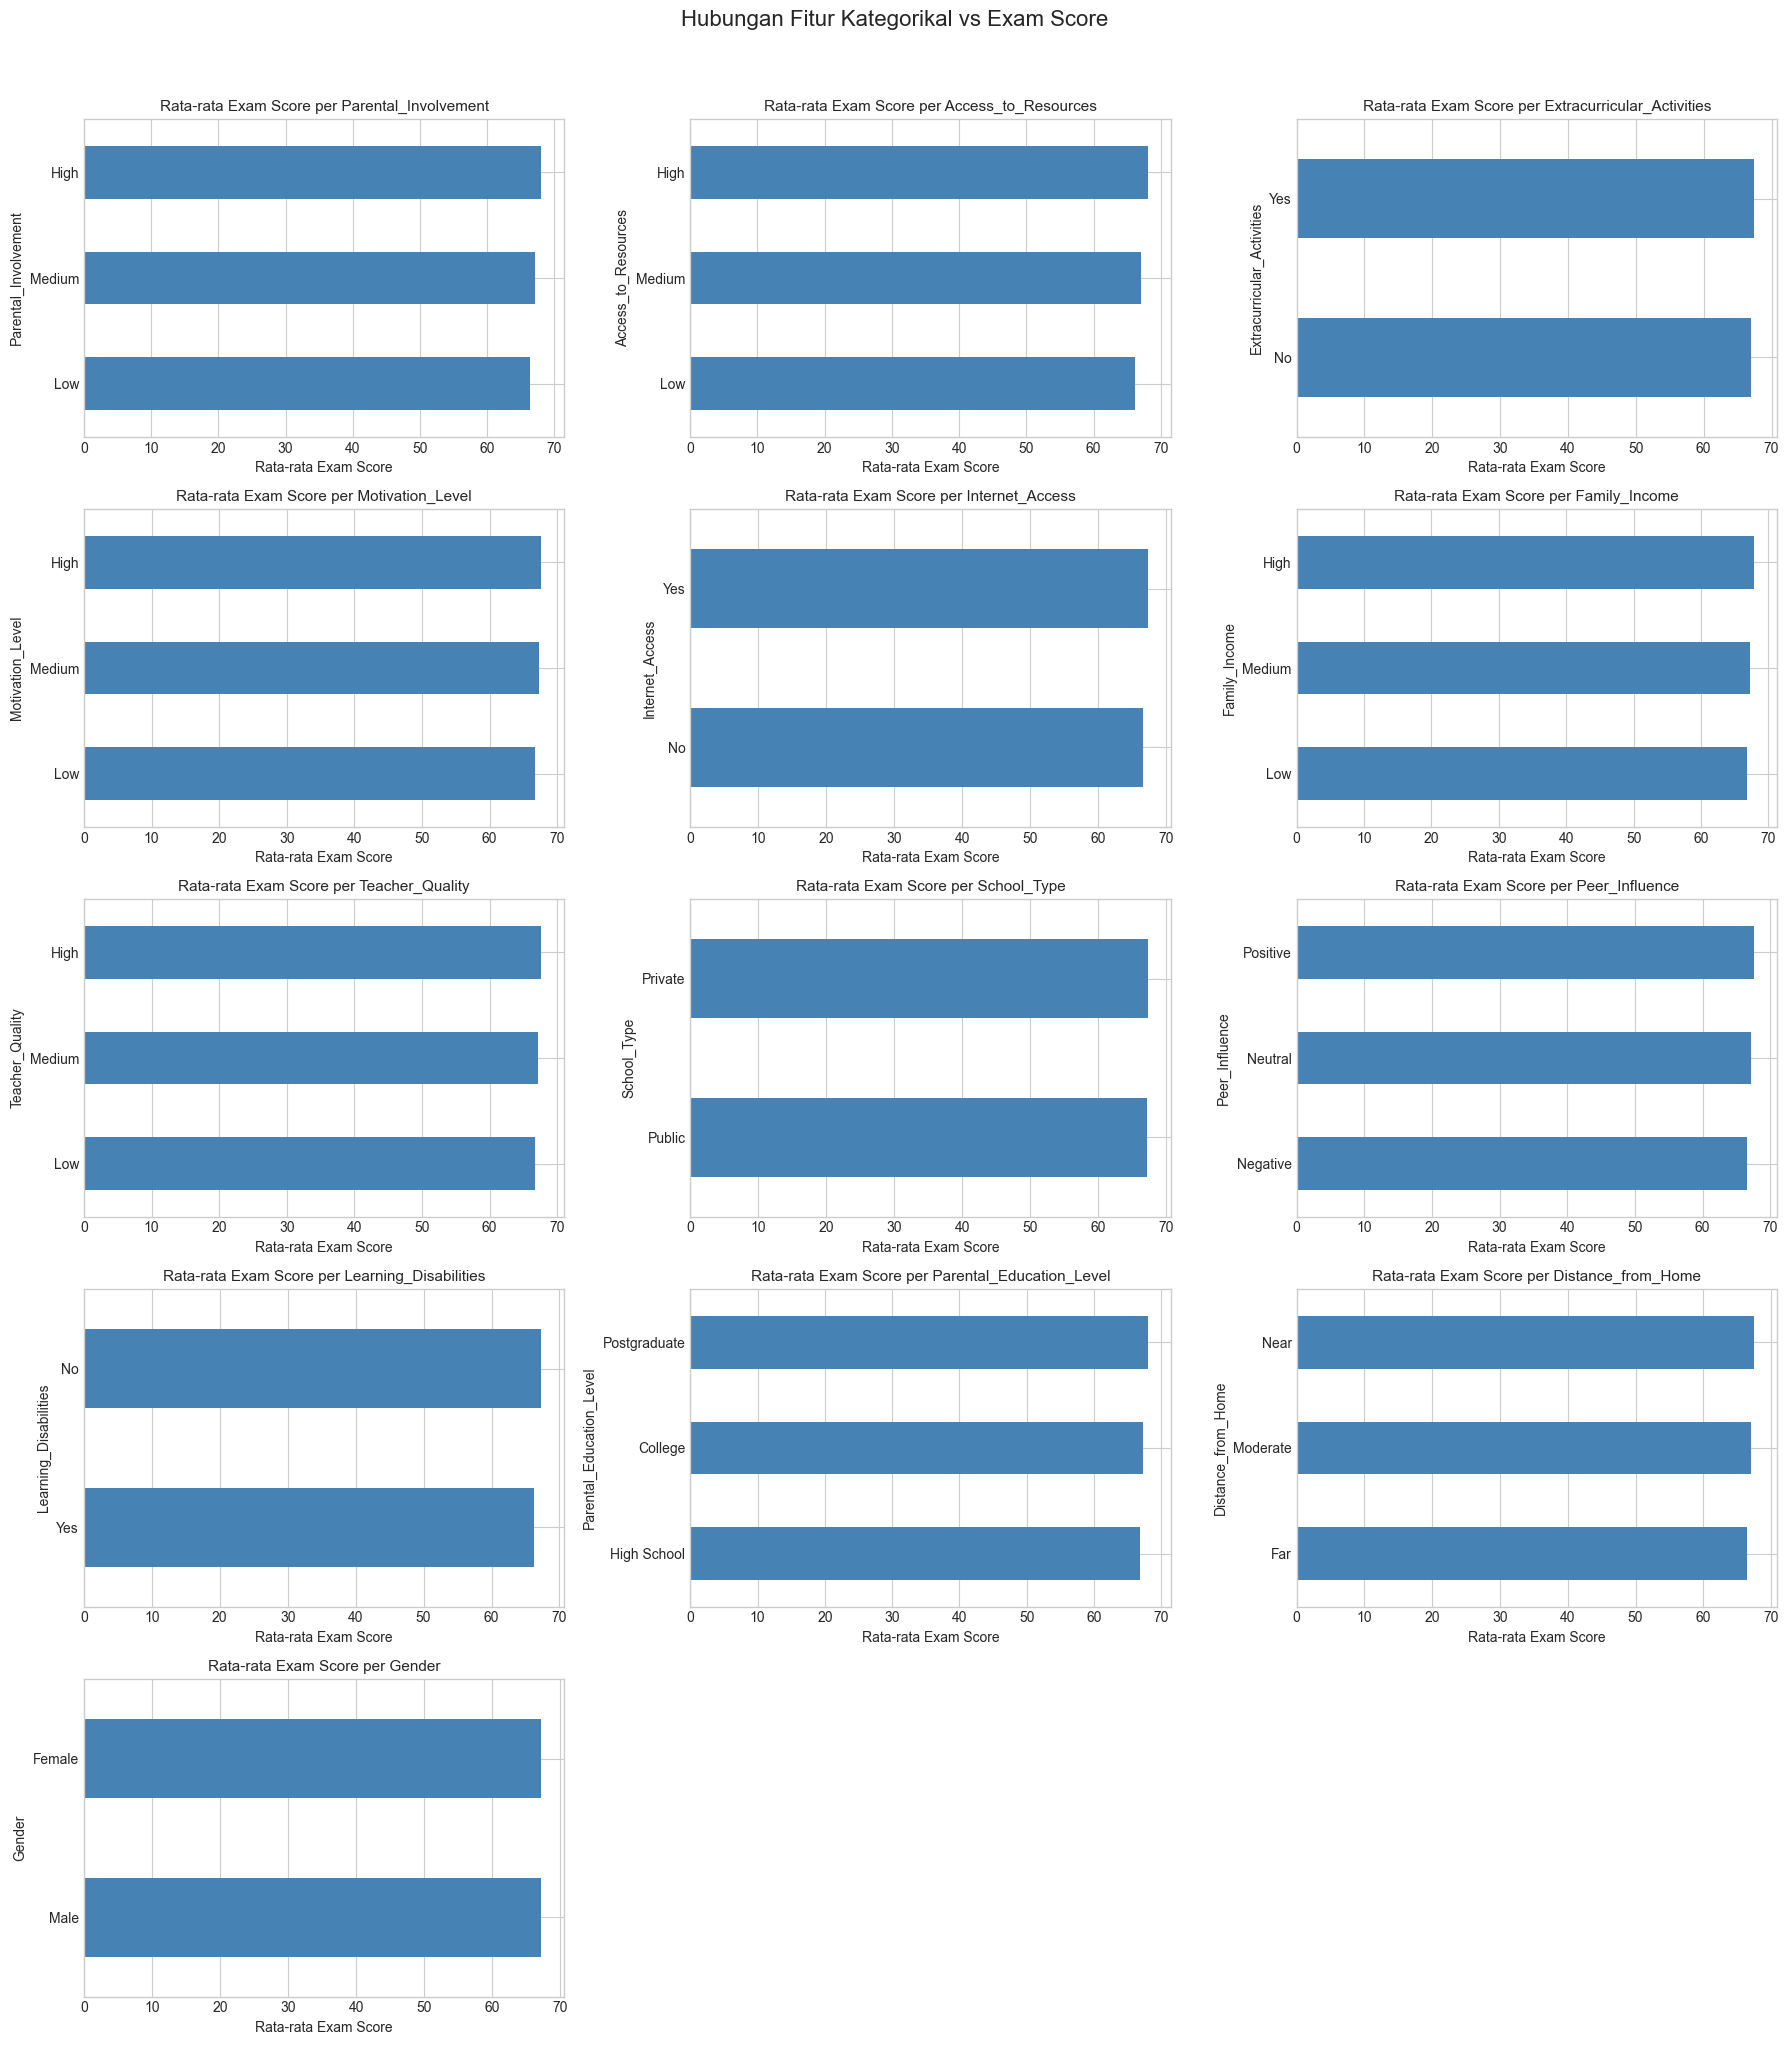

In [41]:
# Rata-rata Exam_Score per kategori
cat_cols = df.select_dtypes(include='object').columns
n = len(cat_cols)
rows = (n + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(18, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    means = df.groupby(col)['Exam_Score'].mean().sort_values()
    means.plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Rata-rata Exam Score per {col}', fontsize=11)
    axes[i].set_xlabel('Rata-rata Exam Score')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Hubungan Fitur Kategorikal vs Exam Score', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [42]:
# Deteksi outlier menggunakan IQR
print('=== Deteksi Outlier (IQR Method) ===')
for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    if len(outliers) > 0:
        print(f'  {col}: {len(outliers)} outlier(s) (range valid: {lower:.1f} - {upper:.1f})')
    else:
        print(f'  {col}: Tidak ada outlier')

=== Deteksi Outlier (IQR Method) ===
  Hours_Studied: Tidak ada outlier
  Attendance: Tidak ada outlier
  Sleep_Hours: Tidak ada outlier
  Previous_Scores: Tidak ada outlier
  Tutoring_Sessions: 429 outlier(s) (range valid: -0.5 - 3.5)
  Physical_Activity: Tidak ada outlier
  Exam_Score: 90 outlier(s) (range valid: 59.0 - 75.0)


**Insight EDA:**
- Distribusi `Exam_Score` relatif normal/uniform
- Beberapa fitur numerik menunjukkan korelasi positif terhadap `Exam_Score` (terutama `Hours_Studied`, `Attendance`, `Previous_Scores`)
- Fitur kategorikal seperti `Motivation_Level`, `Teacher_Quality`, dan `Parental_Involvement` memiliki pengaruh terhadap rata-rata Exam Score

## Explanatory Analysis — Menjawab Business Questions

### BQ1: Faktor paling berkontribusi terhadap klasifikasi performa siswa

In [43]:
# Buat Performance_Category dari Exam_Score
low_threshold = df['Exam_Score'].quantile(0.33)
high_threshold = df['Exam_Score'].quantile(0.66)

def categorize_performance(score):
    if score <= low_threshold: return 'Low'
    elif score <= high_threshold: return 'Medium'
    else: return 'High'

df['Performance_Category'] = df['Exam_Score'].apply(categorize_performance)
print('Distribusi Performance_Category:')
print(df['Performance_Category'].value_counts())

Distribusi Performance_Category:
Performance_Category
Low       2850
High      2220
Medium    1472
Name: count, dtype: int64


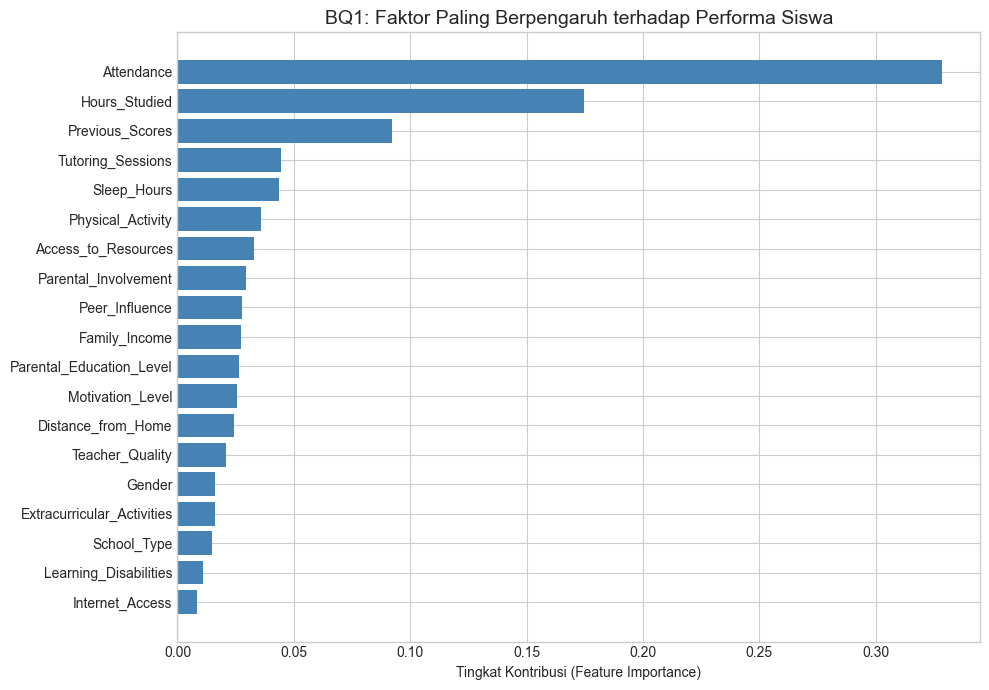


=== Top 5 Faktor Paling Berpengaruh ===
  Attendance               : 0.3285
  Hours_Studied            : 0.1748
  Previous_Scores          : 0.0920
  Tutoring_Sessions        : 0.0444
  Sleep_Hours              : 0.0437


In [44]:
# Temporary encoding untuk feature importance
le = LabelEncoder()
df_temp = df.copy()
for col in df_temp.select_dtypes(include=['object']).columns:
    if col != 'Performance_Category':
        df_temp[col] = le.fit_transform(df_temp[col])

X_temp = df_temp.drop(['Exam_Score', 'Performance_Category'], axis=1)
y_temp = df_temp['Performance_Category']

X_train, X_test, y_train, y_test = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = pd.DataFrame({
    'Faktor': X_temp.columns,
    'Kontribusi': rf.feature_importances_
}).sort_values(by='Kontribusi', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(importances['Faktor'], importances['Kontribusi'], color='steelblue')
plt.title('BQ1: Faktor Paling Berpengaruh terhadap Performa Siswa', fontsize=14)
plt.xlabel('Tingkat Kontribusi (Feature Importance)')
plt.tight_layout()
plt.show()

print('\n=== Top 5 Faktor Paling Berpengaruh ===')
top5 = importances.tail(5).iloc[::-1]
for _, row in top5.iterrows():
    print(f"  {row['Faktor']:25s}: {row['Kontribusi']:.4f}")

**Jawaban BQ1:**
Berdasarkan analisis Feature Importance menggunakan Random Forest, faktor-faktor yang paling berkontribusi terhadap klasifikasi performa siswa ditampilkan pada chart di atas. Adapun kehadiran merupakan hal yang terpenting dan mempengaruhi, hal ini sejalan dengan bagaimana kehadiran pada kelas yang diikuti dapat memberikan berbagai macam manfaat bagi pelajar seperti tidak tertinggal dengan teman yang hadir, belajar secara bertahap melalui kehadiran yang konsisten. Diikuti dengan jam belajar yang juga merupakan faktor penting, hal ini menandakan kehadiran tidak akan cukup bila tidak diikuti dengan jam belajar yang seimbang.

### BQ2: Profil siswa dengan performa rendah

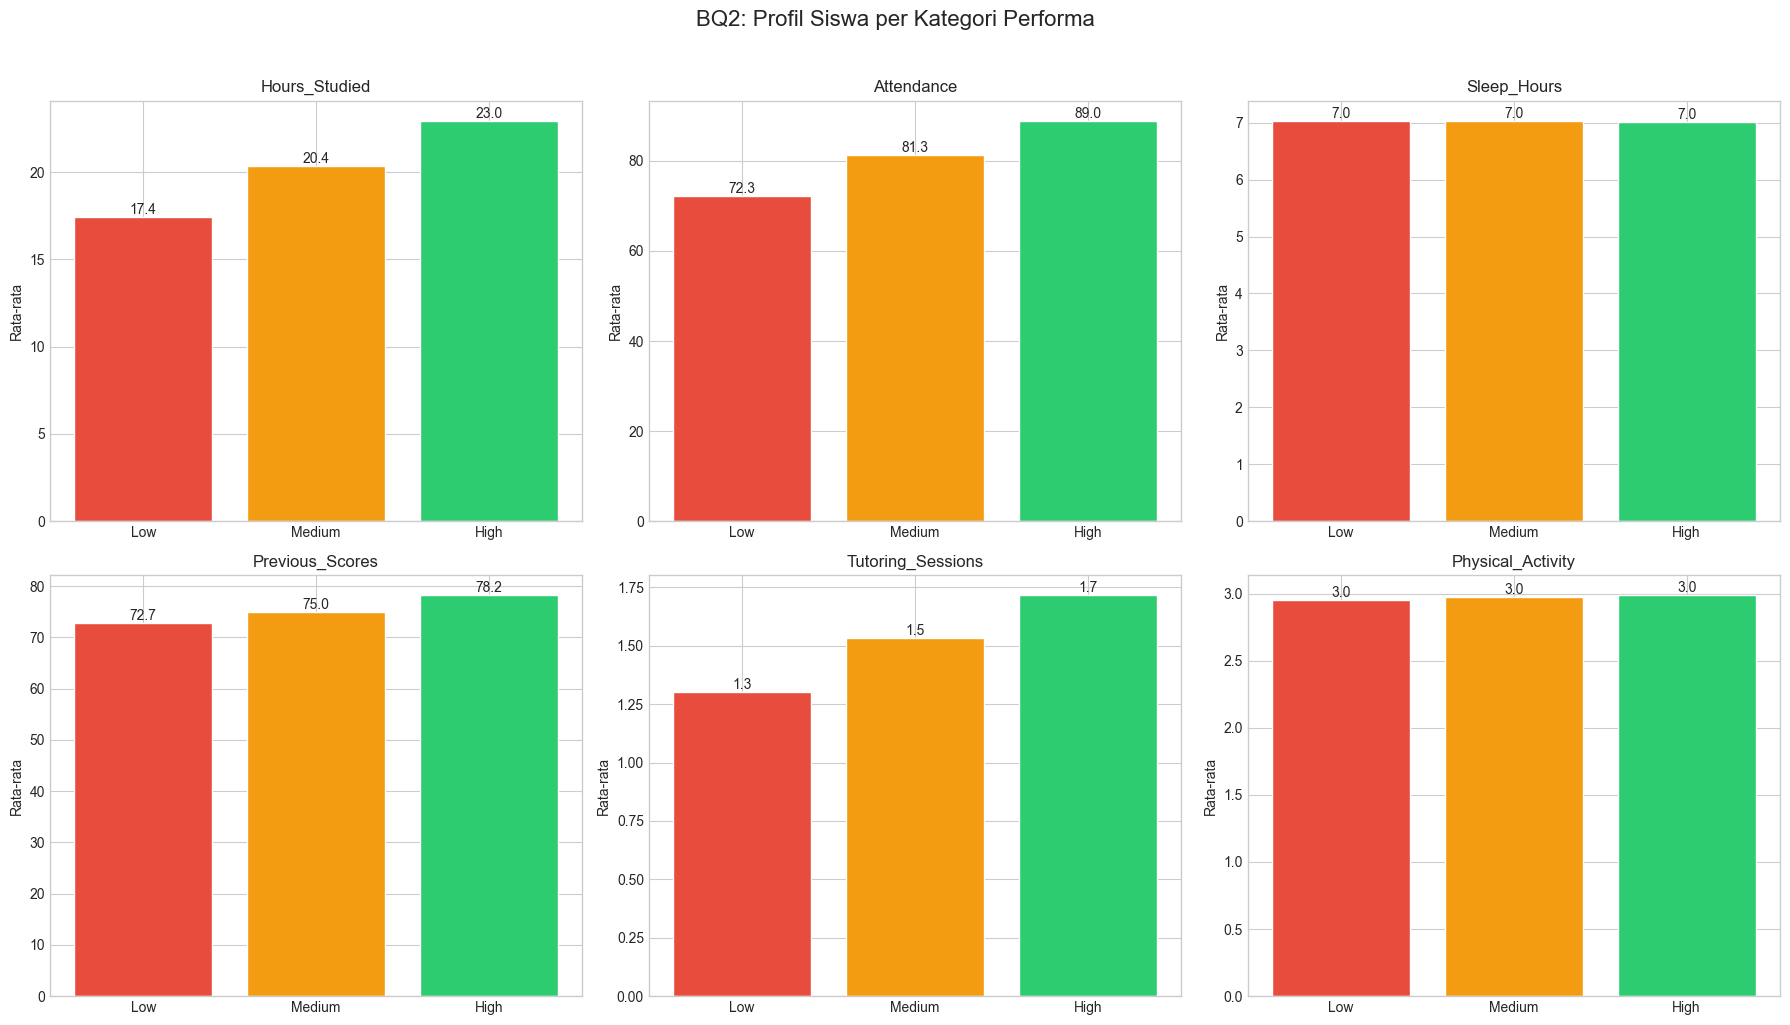

In [45]:
# Bandingkan rata-rata fitur numerik per kategori performa
perf_means = df.groupby('Performance_Category')[['Hours_Studied', 'Attendance',
    'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']].mean()

# Reorder
perf_means = perf_means.reindex(['Low', 'Medium', 'High'])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
colors = {'Low': '#e74c3c', 'Medium': '#f39c12', 'High': '#2ecc71'}

for i, col in enumerate(perf_means.columns):
    bars = axes[i].bar(perf_means.index, perf_means[col],
                       color=[colors[c] for c in perf_means.index], edgecolor='white')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('Rata-rata')
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., h,
                     f'{h:.1f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('BQ2: Profil Siswa per Kategori Performa', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

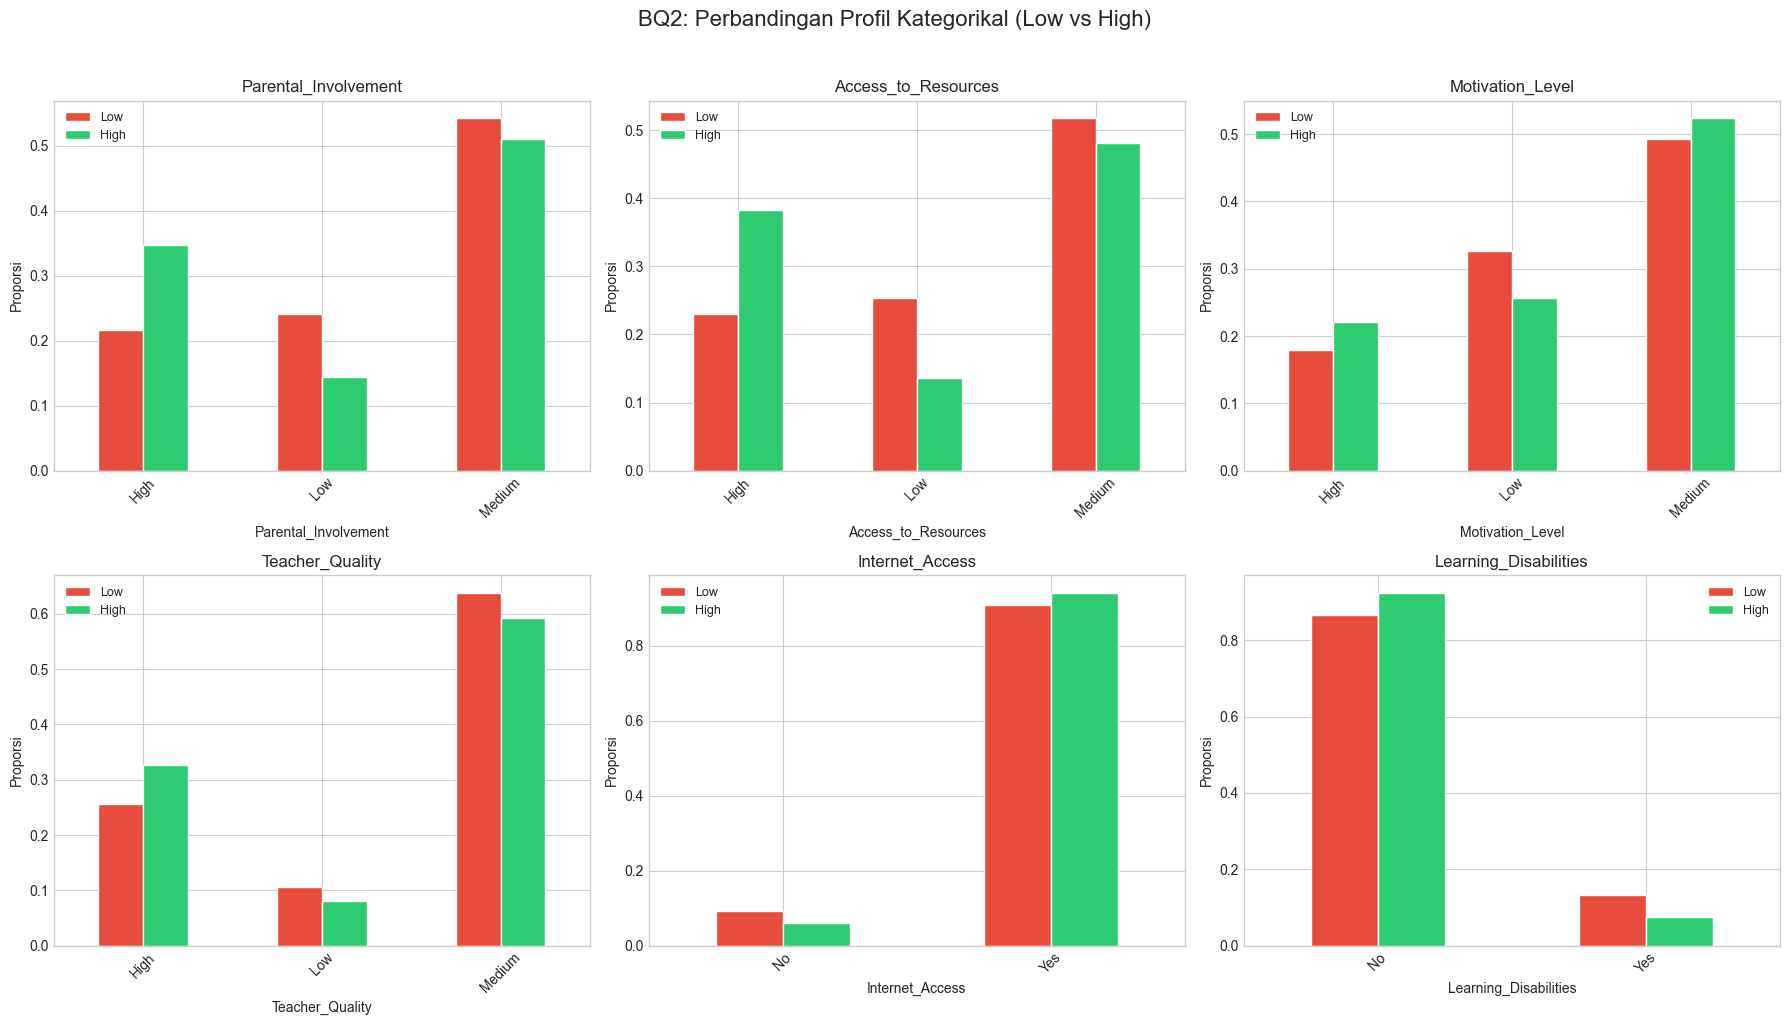

In [46]:
# Profil kategorikal siswa Low vs High
cat_features = ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level',
                'Teacher_Quality', 'Internet_Access', 'Learning_Disabilities']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    low = df[df['Performance_Category'] == 'Low'][col].value_counts(normalize=True).sort_index()
    high = df[df['Performance_Category'] == 'High'][col].value_counts(normalize=True).sort_index()
    comparison = pd.DataFrame({'Low': low, 'High': high}).fillna(0)
    comparison.plot(kind='bar', ax=axes[i], color=['#e74c3c', '#2ecc71'], edgecolor='white')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('Proporsi')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(fontsize=9)

plt.suptitle('BQ2: Perbandingan Profil Kategorikal (Low vs High)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Jawaban BQ2:**
Siswa dengan performa rendah cenderung memiliki:
- Jam belajar yang lebih sedikit
- Tingkat kehadiran yang lebih rendah
- Skor lama yang lebih rendah
- Dukungan orang tua dan motivasi yang lebih rendah
- Akses terhadap sumber belajar yang lebih terbatas

Berdasarkan hal ini, kita dapat menyatakan bahwa strategi yang dapat diterapkan oleh pihak yang berwenang adalah seperti memberikan sosialisasi terhadap orangtua akan pentingnya dukungan bagi progres belajar anak dan juga memberikan akses belajar yang memadai. Selain itu dapat disimpulkan juga bahwa sebagian pelajar yang kurang belajar dan kurang aktif dalam kehadiran akan berakhir memiliki performa yang buruk.

### BQ3: Intervensi akademik potensial

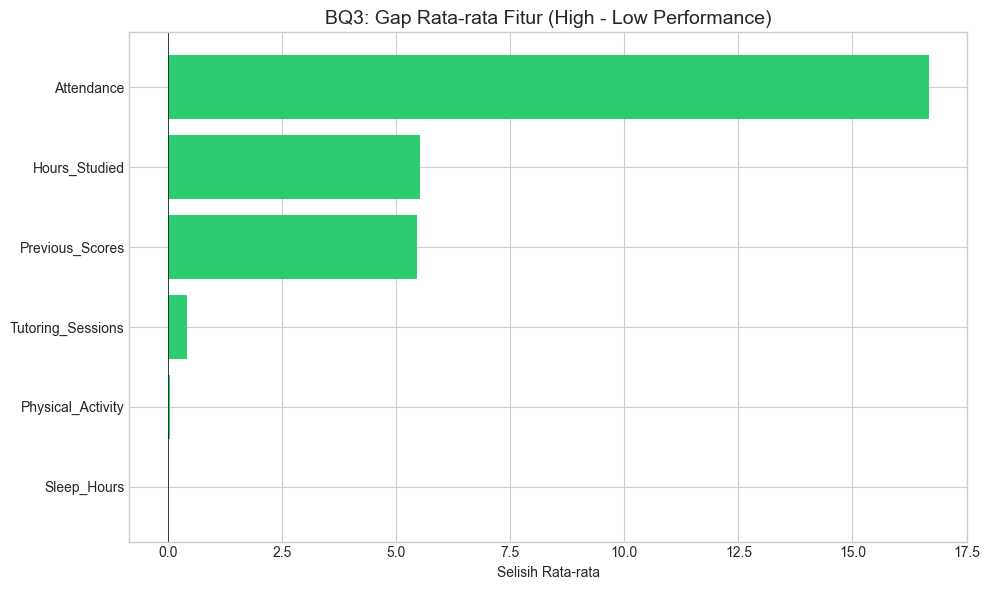


=== Gap Fitur (High - Low) ===
  Sleep_Hours              : -0.02
  Physical_Activity        : +0.03
  Tutoring_Sessions        : +0.41
  Previous_Scores          : +5.44
  Hours_Studied            : +5.53
  Attendance               : +16.68


In [47]:
# Hitung gap antara siswa Low dan High
low_means = df[df['Performance_Category'] == 'Low'][['Hours_Studied', 'Attendance',
    'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']].mean()
high_means = df[df['Performance_Category'] == 'High'][['Hours_Studied', 'Attendance',
    'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']].mean()

gap = (high_means - low_means).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in gap.values]
plt.barh(gap.index, gap.values, color=colors)
plt.title('BQ3: Gap Rata-rata Fitur (High - Low Performance)', fontsize=14)
plt.xlabel('Selisih Rata-rata')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('\n=== Gap Fitur (High - Low) ===')
for feat, val in gap.items():
    print(f'  {feat:25s}: {val:+.2f}')

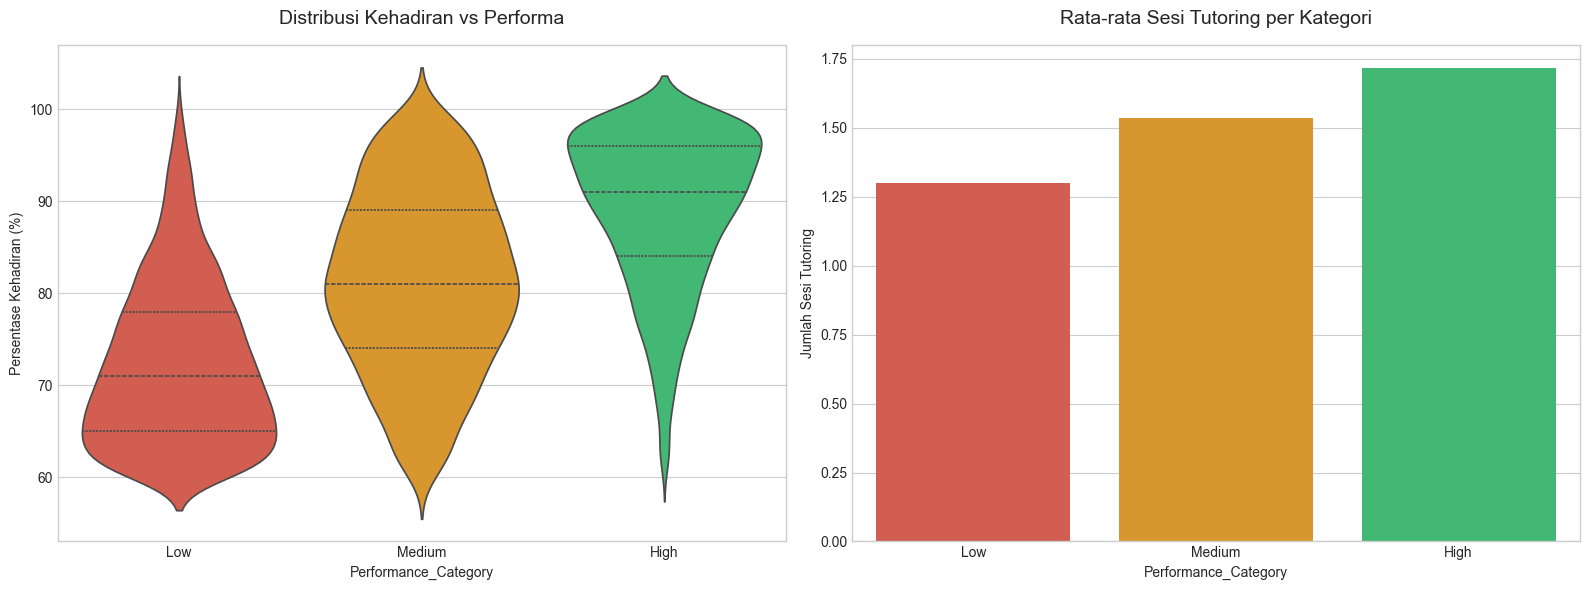

In [48]:
# Analisis fitur kategorikal untuk intervensi
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.violinplot(x='Performance_Category', y='Attendance', data=df,
               order=['Low', 'Medium', 'High'], hue='Performance_Category',
               palette={'Low': '#e74c3c', 'Medium': '#f39c12', 'High': '#2ecc71'},
               legend=False, inner='quartile', ax=ax[0])
ax[0].set_title('Distribusi Kehadiran vs Performa', fontsize=14, pad=15)
ax[0].set_ylabel('Persentase Kehadiran (%)')

sns.barplot(x='Performance_Category', y='Tutoring_Sessions', data=df,
            order=['Low', 'Medium', 'High'], hue='Performance_Category',
            palette={'Low': '#e74c3c', 'Medium': '#f39c12', 'High': '#2ecc71'},
            legend=False, errorbar=None, ax=ax[1])
ax[1].set_title('Rata-rata Sesi Tutoring per Kategori', fontsize=14, pad=15)
ax[1].set_ylabel('Jumlah Sesi Tutoring')

plt.tight_layout()
plt.show()

**Jawaban BQ3:**
Berdasarkan analisis gap antara siswa performa tinggi dan rendah, intervensi yang paling potensial meliputi:
1. **Meningkatkan kehadiran** — Gap terbesar terlihat pada kehadiran
2. **Meningkatkan jam belajar** — jam belajar berkorelasi kuat dengan performa
3. **Program tutoring tambahan** — Siswa dengan performa baik cenderung memiliki lebih banyak sesi tutoring
4. **Meningkatkan motivasi & dukungan orang tua** — Faktor non-akademik yang berpengaruh signifikan
5. **Memperbaiki akses ke sumber belajar** — Termasuk akses internet dan bahan belajar

Melalui beberapa perbandingan diatas, dapat disimpulkan bahwa meningkatkan motivasi sekaligus meningkatkan jam dan kehadiran belajar akan meningkatkan performa pelajar, selain itu faktor eksternal seperti dukungan orangtua dan akses belajar yang memadai akan memberikan dukungan lebih terhadap peningkatan performa belajar.

## Feature Engineering
Menghasilkan fitur yang lebih informatif untuk model.

In [49]:
# ============================================================
# 1. ORDINAL ENCODING - fitur dengan urutan natural
# ============================================================
df_final = df.copy()

ordinal_low_med_high = {'Low': 0, 'Medium': 1, 'High': 2}
for col in ['Parental_Involvement', 'Access_to_Resources',
            'Motivation_Level', 'Family_Income', 'Teacher_Quality']:
    df_final[col] = df_final[col].map(ordinal_low_med_high)

df_final['Distance_from_Home'] = df_final['Distance_from_Home'].map(
    {'Near': 0, 'Moderate': 1, 'Far': 2})

df_final['Peer_Influence'] = df_final['Peer_Influence'].map(
    {'Negative': 0, 'Neutral': 1, 'Positive': 2})

df_final['Parental_Education_Level'] = df_final['Parental_Education_Level'].map(
    {'High School': 0, 'College': 1, 'Postgraduate': 2})

print('Ordinal encoding selesai.')
print('Kolom:', ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level',
       'Family_Income', 'Teacher_Quality', 'Distance_from_Home',
       'Peer_Influence', 'Parental_Education_Level'])

Ordinal encoding selesai.
Kolom: ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 'Family_Income', 'Teacher_Quality', 'Distance_from_Home', 'Peer_Influence', 'Parental_Education_Level']


In [50]:
# ============================================================
# 2. BINARY ENCODING - fitur Yes/No dan Gender/School
# ============================================================
binary_yes_no = {'Yes': 1, 'No': 0}
for col in ['Extracurricular_Activities', 'Internet_Access', 'Learning_Disabilities']:
    df_final[col] = df_final[col].map(binary_yes_no)

df_final['Gender'] = df_final['Gender'].map({'Male': 0, 'Female': 1})
df_final['School_Type'] = df_final['School_Type'].map({'Public': 0, 'Private': 1})

print('Binary encoding selesai.')
print('Kolom:', ['Extracurricular_Activities', 'Internet_Access',
       'Learning_Disabilities', 'Gender', 'School_Type'])

Binary encoding selesai.
Kolom: ['Extracurricular_Activities', 'Internet_Access', 'Learning_Disabilities', 'Gender', 'School_Type']


In [51]:
# ============================================================
# 3. INTERACTION FEATURES - kombinasi fitur yang saling terkait
# ============================================================

# Efisiensi belajar: skor per jam belajar
df_final['Study_Efficiency'] = df_final['Previous_Scores'] / (df_final['Hours_Studied'] + 1)

# Engagement score: kehadiran × jam belajar
df_final['Engagement_Score'] = df_final['Attendance'] * df_final['Hours_Studied'] / 100

# Rasio tidur-belajar
df_final['Sleep_Study_Ratio'] = df_final['Sleep_Hours'] / (df_final['Hours_Studied'] + 1)

print('Interaction features ditambahkan:')
print('  - Study_Efficiency = Previous_Scores / (Hours_Studied + 1)')
print('  - Engagement_Score = Attendance * Hours_Studied / 100')
print('  - Sleep_Study_Ratio = Sleep_Hours / (Hours_Studied + 1)')

Interaction features ditambahkan:
  - Study_Efficiency = Previous_Scores / (Hours_Studied + 1)
  - Engagement_Score = Attendance * Hours_Studied / 100
  - Sleep_Study_Ratio = Sleep_Hours / (Hours_Studied + 1)


In [52]:
# ============================================================
# 4. COMPOSITE FEATURES - skor gabungan
# ============================================================

# Support Score: dukungan lingkungan
df_final['Support_Score'] = (
    df_final['Parental_Involvement'] +
    df_final['Access_to_Resources'] +
    df_final['Internet_Access'] +
    df_final['Family_Income']
) / 4

# Academic Readiness: kesiapan akademik
max_tutoring = df_final['Tutoring_Sessions'].max()
df_final['Academic_Readiness'] = (
    df_final['Previous_Scores'] / 100 * 0.4 +
    df_final['Motivation_Level'] / 2 * 0.3 +
    df_final['Tutoring_Sessions'] / max_tutoring * 0.3
)

print('Composite features ditambahkan:')
print('  - Support_Score')
print('  - Academic_Readiness')

Composite features ditambahkan:
  - Support_Score
  - Academic_Readiness


In [53]:
# ============================================================
# 5. FINALISASI: Drop Exam_Score, pertahankan Performance_Category
# ============================================================
# Performance_Category sudah dibuat di Section 8
# Exam_Score DIHAPUS karena bukan input user

df_final = df_final.drop('Exam_Score', axis=1)

print(f'Dataset final: {df_final.shape[0]} baris, {df_final.shape[1]} kolom')
print(f'Target: Performance_Category')
print(f'Fitur: {df_final.shape[1] - 1} kolom')
print(f'\nKolom: {list(df_final.columns)}')

Dataset final: 6542 baris, 25 kolom
Target: Performance_Category
Fitur: 24 kolom

Kolom: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Performance_Category', 'Study_Efficiency', 'Engagement_Score', 'Sleep_Study_Ratio', 'Support_Score', 'Academic_Readiness']


## Penjelasan Mengenai Feature Engineering
### 1. Ordinal Encoding
Kolom-kolom kategorikal yang memiliki **urutan natural (hierarki)** diubah menjadi representasi numerik

**Alasan:** Fitur-fitur ini bersifat ordinal — artinya terdapat urutan yang bermakna antar kategori (misalnya Low < Medium < High). Ordinal encoding dipilih karena mampu mempertahankan informasi urutan tersebut dalam bentuk numerik, sehingga model dapat memahami bahwa `High` (2) lebih besar daripada `Low` (0). Metode ini lebih tepat dibandingkan one-hot encoding karena one-hot encoding akan menghilangkan informasi hierarki antar kategori.

### 2. Binary Encoding
Kolom-kolom kategorikal dengan **dua nilai (biner)** diubah menjadi 0 dan 1

**Alasan:** Fitur-fitur biner hanya memiliki dua kemungkinan nilai, sehingga cukup direpresentasikan dengan 0 dan 1. Transformasi ini diperlukan karena model machine learning membutuhkan input numerik dan tidak dapat memproses data bertipe string secara langsung.

### 3. Interaction Features
Tiga fitur baru diciptakan dari **kombinasi fitur-fitur yang saling berkaitan**

**Alasan:** Fitur individual sering kali tidak cukup menangkap pola kompleks dalam data. Dengan mengkombinasikan fitur-fitur yang secara logis saling terkait, interaction features mampu mengungkap hubungan non-linear yang tersembunyi. Contohnya:
- Dua siswa bisa sama-sama mendapat skor 80, tetapi yang satu belajar 10 jam dan yang lain 30 jam — `Study_Efficiency` menangkap perbedaan penting ini.
- Siswa dengan kehadiran tinggi DAN jam belajar tinggi secara bersamaan menunjukkan engagement yang lebih kuat dibanding siswa yang hanya unggul di salah satunya.
- Rasio tidur-belajar membantu model mendeteksi pola siswa yang mungkin kurang tidur karena terlalu banyak belajar, atau sebaliknya.

Penambahan `+1` pada pembagi (`Hours_Studied + 1`) dilakukan untuk menghindari pembagian dengan nol (division by zero), hal ini tidak berpengaruh signifikan pada model nantinya.

### 4. Composite Features
Dua fitur komposit dibuat dengan **menggabungkan beberapa variabel terkait** menjadi satu skor tunggal

**Alasan:** Composite features dirancang untuk merangkum sekelompok variabel yang secara konseptual saling berhubungan menjadi satu indikator yang lebih bermakna:
- **`Support_Score`** menggabungkan empat faktor dukungan lingkungan (keterlibatan orang tua, akses sumber belajar, akses internet, dan pendapatan keluarga) menjadi satu skor tunggal (range 0–2). Hal ini didasari temuan dari EDA bahwa faktor-faktor eksternal ini secara bersama-sama mempengaruhi performa siswa.
- **`Academic_Readiness`** menggunakan weighted average dengan bobot: skor sebelumnya (40%), tingkat motivasi (30%), dan sesi tutoring (30%). Bobot ini mencerminkan bahwa kemampuan akademik masa lalu memiliki pengaruh paling besar, sementara motivasi dan dukungan tutoring memiliki kontribusi yang setara. Range skor dinormalisasi ke 0–1.

### 5. Finalisasi Dataset
Pada tahap akhir, kolom `Exam_Score` **dihapus** dari dataset final.

**Alasan:** Dalam konteks aplikasi prediksi performa siswa, `Exam_Score` adalah variabel yang digunakan untuk menurunkan target (`Performance_Category`), bukan fitur input dari user. Jika `Exam_Score` tetap dipertahankan sebagai fitur, maka akan terjadi **data leakage** — yaitu kondisi di mana model "melihat" informasi yang seharusnya menjadi output saat proses training, sehingga menghasilkan performa yang tidak realistis.

## Verifikasi Akhir & Export Dataset

In [54]:
# Verifikasi dataset final
print('=== Verifikasi Dataset Final ===')
print(f'Shape: {df_final.shape}')
print(f'Missing values: {df_final.isnull().sum().sum()}')
print(f'Target distribution:')
print(df_final['Performance_Category'].value_counts())
print(f'\nInfo:')
df_final.info()

=== Verifikasi Dataset Final ===
Shape: (6542, 25)
Missing values: 0
Target distribution:
Performance_Category
Low       2850
High      2220
Medium    1472
Name: count, dtype: int64

Info:
<class 'pandas.core.frame.DataFrame'>
Index: 6542 entries, 0 to 6606
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6542 non-null   int64  
 1   Attendance                  6542 non-null   int64  
 2   Parental_Involvement        6542 non-null   int64  
 3   Access_to_Resources         6542 non-null   int64  
 4   Extracurricular_Activities  6542 non-null   int64  
 5   Sleep_Hours                 6542 non-null   float64
 6   Previous_Scores             6542 non-null   int64  
 7   Motivation_Level            6542 non-null   int64  
 8   Internet_Access             6542 non-null   int64  
 9   Tutoring_Sessions           6542 non-null   int64  
 10  Family_Income       

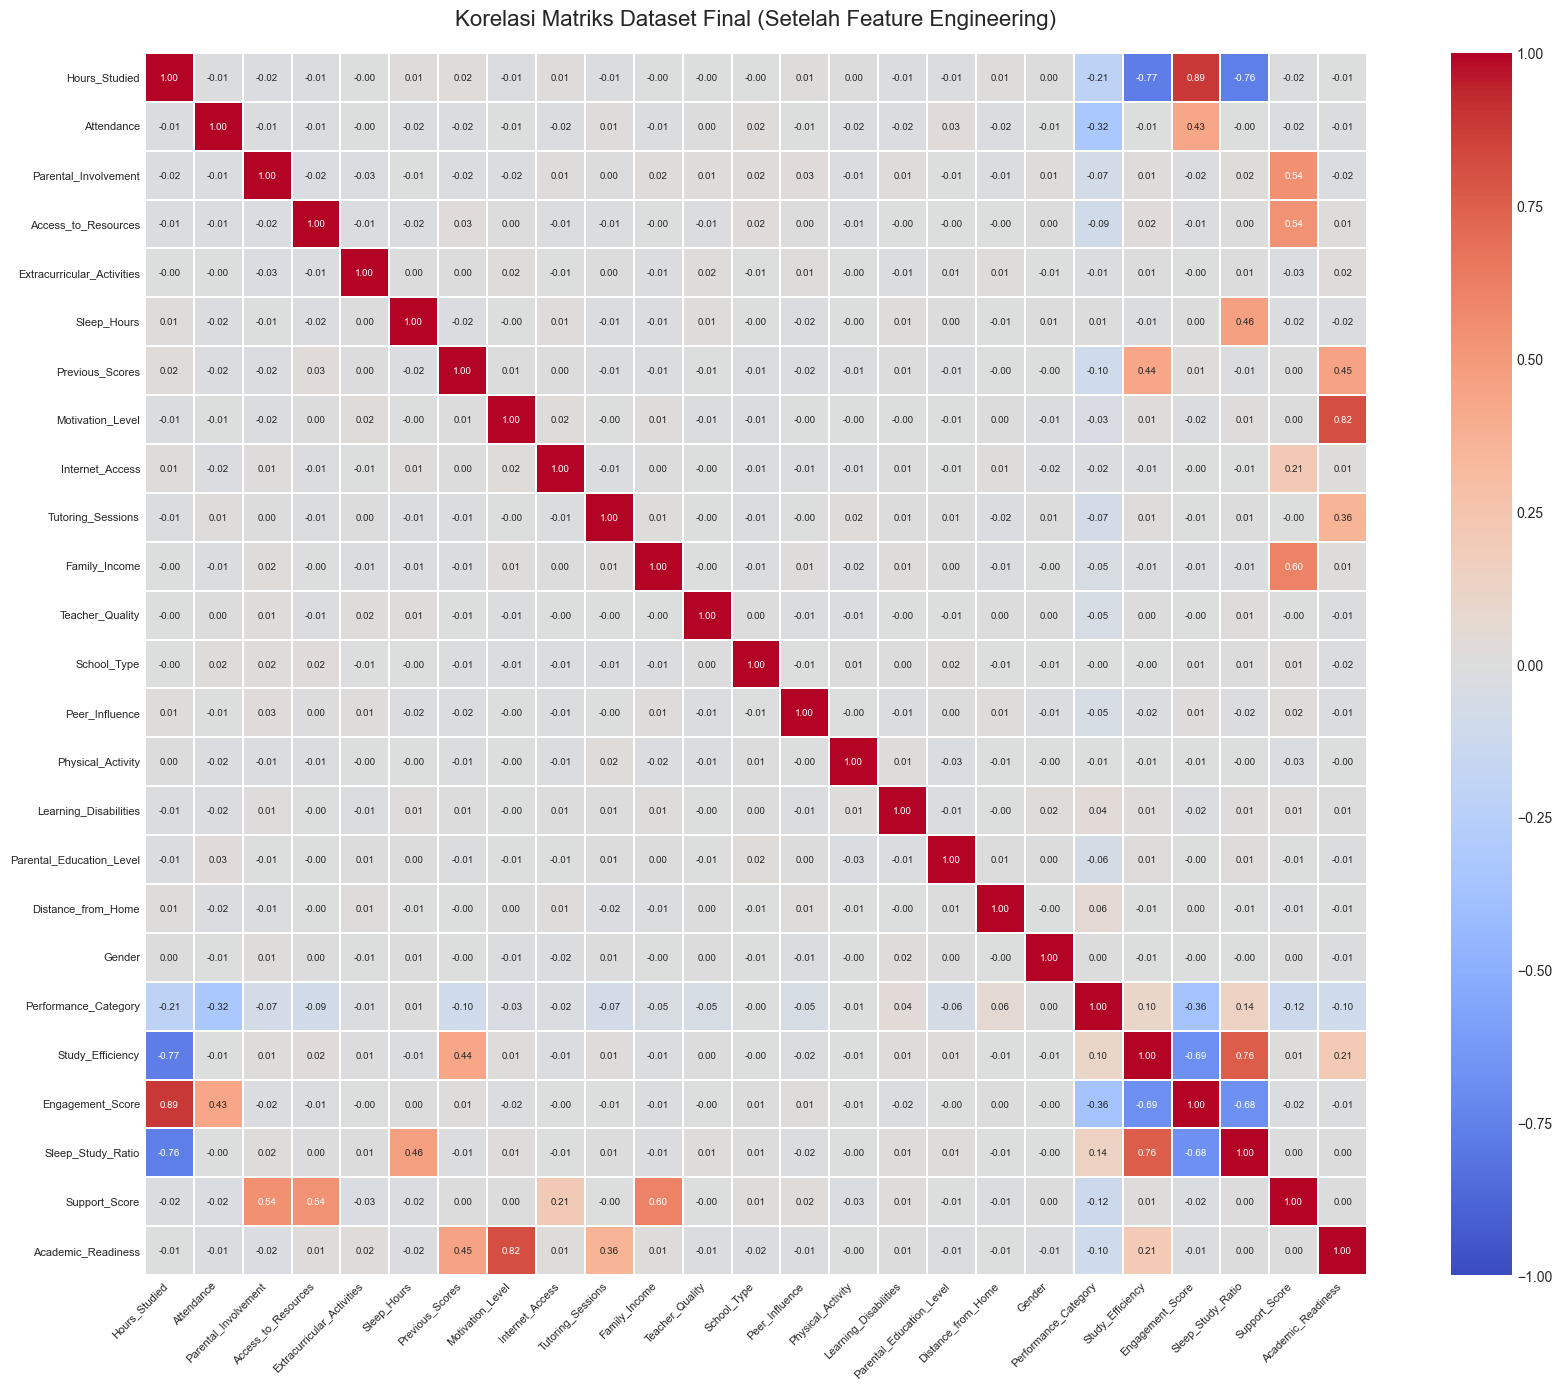

In [55]:
# Korelasi matriks dataset final (setelah full encoding)
le_final = LabelEncoder()
df_corr = df_final.copy()
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = le_final.fit_transform(df_corr[col])

plt.figure(figsize=(18, 14))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.3, vmin=-1, vmax=1,
            annot_kws={'size': 7})
plt.title('Korelasi Matriks Dataset Final (Setelah Feature Engineering)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [56]:
# Export dataset siap pakai untuk tim AI Engineer dan Analis
output_path = 'student_performance_dataset.csv'
df_final.to_csv(output_path, index=False)
print(f'Dataset berhasil di-export ke: {output_path}')
print(f'Ukuran: {df_final.shape[0]} baris × {df_final.shape[1]} kolom')
print(f'\nDataset ini siap digunakan oleh tim AI Engineer untuk:')
print('  1. Training model prediksi Performance_Category')
print('  2. Membangun sistem rekomendasi intervensi akademik')

# Export dataset siap pakai untuk analisis (tanpa encoding)
analysis_output_path = 'StudentPerformanceFactors_analysis.csv'
df.to_csv(analysis_output_path, index=False)
print(f'Dataset analisis berhasil di-export ke: {analysis_output_path}')
print(f'Ukuran: {df.shape[0]} baris × {df.shape[1]} kolom')
print('  3. Visualisasi Dashboard')


Dataset berhasil di-export ke: student_performance_dataset.csv
Ukuran: 6542 baris × 25 kolom

Dataset ini siap digunakan oleh tim AI Engineer untuk:
  1. Training model prediksi Performance_Category
  2. Membangun sistem rekomendasi intervensi akademik
Dataset analisis berhasil di-export ke: StudentPerformanceFactors_analysis.csv
Ukuran: 6542 baris × 21 kolom
  3. Visualisasi Dashboard
